In [21]:
import pickle
from representation_analysis import compute_rate_maps_single
from plotting import plot_units_rate_maps
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from ratinabox.Environment import Environment
from ratinabox.Agent import Agent
from viz import display_reward_patch
import numpy as np


In [2]:
relu_data_out = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/ReLU/env_empty/seed_0/all_out_arrays_seed_0", "rb"))
relu_data_bins = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/ReLU/env_empty/seed_0/all_episodes_bins_seed_0", "rb"))
relu_data_states = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/ReLU/env_empty/seed_0/all_episodes_states_seed_0", "rb"))
fta_data_out = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_empty/seed_0/all_out_arrays_seed_0", "rb"))
fta_data_bins = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_empty/seed_0/all_episodes_bins_seed_0", "rb"))
fta_data_states = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_empty/seed_0/all_episodes_states_seed_0", "rb"))

In [8]:
OBSTACLES = {
    "empty": [],

    "obstacle_near_goal": [
        {"x_min": 0.30, "x_max": 0.45, "y_min": 0.30, "y_max": 0.45}
    ],

    "obstacle_corners": [
        # bottom-left
        {"x_min": 0.0,  "x_max": 0.15, "y_min": 0.0,  "y_max": 0.15},

        # bottom-right
        {"x_min": 0.85, "x_max": 1.0,  "y_min": 0.0,  "y_max": 0.15},

        # top-left
        {"x_min": 0.0,  "x_max": 0.15, "y_min": 0.85, "y_max": 1.0},

        # top-right
        {"x_min": 0.85, "x_max": 1.0,  "y_min": 0.85, "y_max": 1.0},
    ],
}
fta_data_states_corners = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_obstacle_corners/seed_0/all_episodes_states_seed_0", "rb"))
fta_data_out_corners = pickle.load(open("/Users/mariedelvalle/Documents/projects/RatInABox/data/FTA/env_obstacle_corners/seed_0/all_out_arrays_seed_0", "rb"))

In [12]:
fta_data_states_corners[1]

[array([0.93157322, 0.3396419 ]),
 array([0.9359161 , 0.33581929]),
 array([0.94022139, 0.32833932]),
 array([0.94778898, 0.32543877]),
 array([0.95264361, 0.32020312]),
 array([0.95576411, 0.316072  ]),
 array([0.96064371, 0.31459335]),
 array([0.96128447, 0.31181481]),
 array([0.96139866, 0.31037081]),
 array([0.96274266, 0.30860971]),
 array([0.96422119, 0.30824954]),
 array([0.96886902, 0.31025895]),
 array([0.97130939, 0.31173122]),
 array([0.97130814, 0.3072568 ]),
 array([0.96927867, 0.3043117 ]),
 array([0.96682166, 0.30126849]),
 array([0.96458978, 0.29591966]),
 array([0.96058141, 0.29455424]),
 array([0.95585532, 0.29400736]),
 array([0.95192857, 0.29551711]),
 array([0.94554631, 0.29746161]),
 array([0.94259517, 0.29898657]),
 array([0.935098  , 0.30032225]),
 array([0.9270426 , 0.30256292]),
 array([0.92278212, 0.30670054]),
 array([0.91633423, 0.31111178]),
 array([0.91322209, 0.31336196]),
 array([0.90935469, 0.31526274]),
 array([0.90652493, 0.31915351]),
 array([0.9019

In [9]:
def is_in_obstacle(x, y, obstacles):
    for obs in obstacles:
        if (obs["x_min"] <= x <= obs["x_max"] and
            obs["y_min"] <= y <= obs["y_max"]):
            return True
    return False

def check_activation_in_obstacles(states, out_arrays, obstacles, threshold=0.0):
    """
    Check whether any activations occur inside obstacle regions.

    Returns:
        total_points_in_obstacles
        total_active_points_in_obstacles
    """

    total_points = 0
    active_points = 0

    for ep_states, ep_outs in zip(states, out_arrays):
        for (x, y), out in zip(ep_states, ep_outs):

            if is_in_obstacle(x, y, obstacles):
                total_points += 1

                # Check if ANY unit is active
                if np.any(np.array(out) > threshold):
                    active_points += 1

    return total_points, active_points

In [10]:
obstacles = OBSTACLES['obstacle_corners']

total, active = check_activation_in_obstacles(
    fta_data_states_corners,
    fta_data_out_corners,
    obstacles,
    threshold=0.1
)

print(f"Points inside obstacles: {total}")
print(f"Active points inside obstacles: {active}")

Points inside obstacles: 0
Active points inside obstacles: 0


(<Figure size 250x250 with 1 Axes>, <Axes: >)

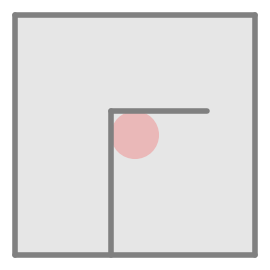

In [60]:
env = Environment()
env.add_wall([[.40, .0], [.40, .60]])
env.add_wall([[0.40, 0.60], [0.80, 0.60]])
resolution = 0.01  # spacing between walls
    
fig, ax =env.plot_environment()
display_reward_patch(fig, ax, reward_location=[0.5, 0.5], reward_radius=0.1)


(<Figure size 250x250 with 1 Axes>, <Axes: >)

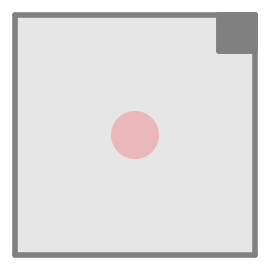

In [62]:
env = Environment()
env.add_wall([[0.85, 0.85], [0.85, 1.0]])
env.add_wall([[0.85, 1.0], [1.0, 1.0]])
env.add_wall([[1.0, 1.0], [1.0, 0.85]])
env.add_wall([[1.0, 0.85], [0.85, 0.85]])
resolution = 0.01
for y in np.arange(0.85, 1.0, resolution):
    env.add_wall([[0.85, y], [1.0, y]])
fig, ax =env.plot_environment()
display_reward_patch(fig, ax, reward_location=[0.5, 0.5], reward_radius=0.1)